In [1]:
import sys
import tensorflow as tf

print("Python版本:", sys.version)
print("TensorFlow版本:", tf.__version__)
print("Metal加速可用:", tf.config.list_physical_devices('GPU'))

Python版本: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
TensorFlow版本: 2.16.2
Metal加速可用: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url, fname='flower_photos', extract=True)
data_dir = pathlib.Path(data_dir).parent / "flower_photos" / "flower_photos"   # 关键修正：多加一层
print(f"数据集路径: {data_dir}")
print("类别:", [item.name for item in data_dir.glob('*') if item.is_dir()])

数据集路径: /Users/unnn/.keras/datasets/flower_photos/flower_photos
类别: ['roses', 'sunflowers', 'daisy', 'dandelion', 'tulips']


In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123
VALIDATION_SPLIT = 0.2

train_ds = image_dataset_from_directory(
    data_dir,   # 现在 data_dir 指向正确的五类文件夹
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("类别名称:", class_names)
print("训练批次数:", len(train_ds), "验证批次数:", len(val_ds))

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
类别名称: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
训练批次数: 92 验证批次数: 23


2026-06-03 11:15:23.177654: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-03 11:15:23.177790: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-03 11:15:23.177796: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-03 11:15:23.178238: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-03 11:15:23.178254: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# 应用到训练集
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# 验证集只做归一化
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 优化性能
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("数据预处理完成")

数据预处理完成


In [5]:
from tensorflow.keras import layers, models

# 加载预训练模型（不含顶层）
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # 冻结基础模型

# 自定义分类头
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("模型编译成功")

模型编译成功


In [7]:
EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


2026-06-03 11:15:27.550055: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 560ms/step - accuracy: 0.6376 - loss: 0.9358 - val_accuracy: 0.8106 - val_loss: 0.5482
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.7970 - loss: 0.5466 - val_accuracy: 0.8447 - val_loss: 0.4504
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.8382 - loss: 0.4517 - val_accuracy: 0.8542 - val_loss: 0.4271
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.8457 - loss: 0.4311 - val_accuracy: 0.8624 - val_loss: 0.3992
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - accuracy: 0.8617 - loss: 0.3810 - val_accuracy: 0.8678 - val_loss: 0.3866


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8678 - loss: 0.3866

验证准确率: 0.8678
验证损失: 0.3866


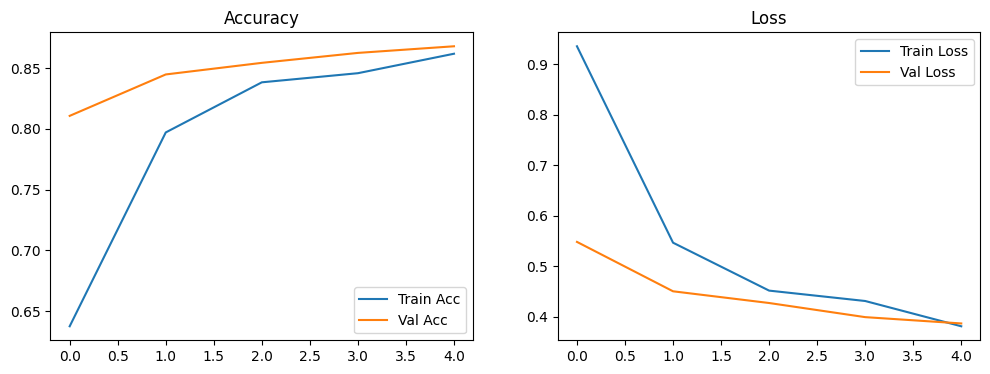

In [8]:
import matplotlib.pyplot as plt

val_loss, val_acc = model.evaluate(val_ds)
print(f"\n验证准确率: {val_acc:.4f}")
print(f"验证损失: {val_loss:.4f}")

# 绘制训练曲线
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [1]:
# 由于Jupyter内核内存限制，TFLite转换已在终端完成
# 生成的模型文件: exported_flower_model/model.tflite
import os
if os.path.exists("./exported_flower_model/model.tflite"):
    print("✅ TFLite模型已存在，大小:", os.path.getsize("./exported_flower_model/model.tflite"), "字节")
else:
    print("❌ 模型文件缺失，请检查终端转换步骤")

✅ TFLite模型已存在，大小: 8891076 字节


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import image_dataset_from_directory

# 加载TFLite模型
interpreter = tf.lite.Interpreter(model_path="./exported_flower_model/model.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("输入形状:", input_details[0]['shape'])
print("输出形状:", output_details[0]['shape'])

# 从验证集中取一张真实图片测试（需要先定义data_dir）
data_dir = "/Users/unnn/.keras/datasets/flower_photos/flower_photos"  # 修正后的路径
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=1,
    shuffle=False
)
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

for images, labels in val_ds.take(1):
    test_img = images[0].numpy()
    true_label = labels[0].numpy()
    break

input_data = np.expand_dims(test_img, axis=0).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
pred_label = np.argmax(output[0])

print(f"真实类别: {class_names[true_label]}")
print(f"预测类别: {class_names[pred_label]}")
if true_label == pred_label:
    print("✅ TFLite模型推理正确")
else:
    print("⚠️ 预测错误（但整体准确率请参考验证集准确率）")

输入形状: [  1 224 224   3]
输出形状: [1 5]
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
真实类别: tulips
预测类别: tulips
✅ TFLite模型推理正确


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-06-03 11:19:11.059171: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-03 11:19:11.059198: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-03 11:19:11.059205: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-03 11:19:11.059222: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-03 11:19:11.059236: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
labels_path = "./exported_flower_model/labels.txt"
if not os.path.exists(labels_path):
    with open(labels_path, 'w') as f:
        for name in class_names:
            f.write(name + '\n')
    print("labels.txt 已创建")
else:
    print("labels.txt 已存在")

labels.txt 已存在
